Files ready on the local disk

--- Fase 1: Warm-up ---
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 100ms/step - accuracy: 0.8743 - auc: 0.9444 - loss: 0.3295 - val_accuracy: 0.8409 - val_auc: 0.9347 - val_loss: 0.3881
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9104 - auc: 0.9694 - loss: 0.2416 - val_accuracy: 0.8345 - val_auc: 0.9366 - val_loss: 0.4191
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9224 - auc: 0.9757 - loss: 0.2136 - val_accuracy: 0.8330 - val_auc: 0.9237 - val_loss: 0.4114

--- Fase 2: Fine-Tuning ---
Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 117s 114ms/step - accuracy: 0.9328 - auc: 0.9814 - loss: 0.6399 - val_accuracy: 0.8518 - val_auc: 0.9347 - val_loss: 0.4758 - learning_rate: 1.0000e-05
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9278 - auc: 0.9822 - loss: 0.5852 - val_accuracy: 0.8560 - val_auc: 0.9362 - val_loss: 0.4498 - learning_rate: 1.0000e-05
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/

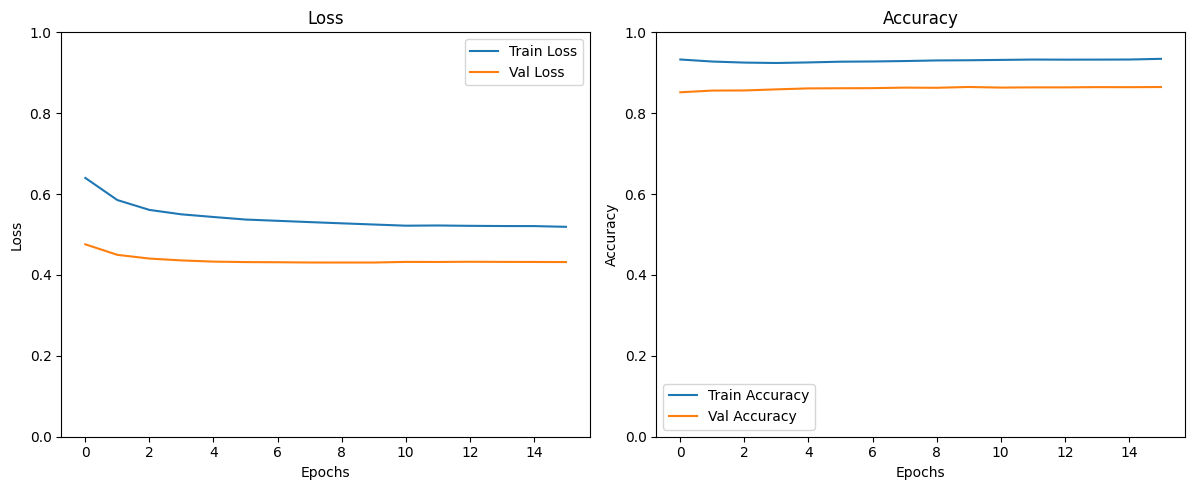


 Final evaluation on test set using streaming pipelines...
256/256 ━━━━━━━━━━━━━━━━━━━━ 36s 82ms/step

--- Final report (Threshold: 0.35) ---
              precision    recall  f1-score   support

     Healthy       0.84      0.83      0.84     16391
       Tumor       0.83      0.85      0.84     16377

    accuracy                           0.84     32768
   macro avg       0.84      0.84      0.84     32768
weighted avg       0.84      0.84      0.84     32768



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


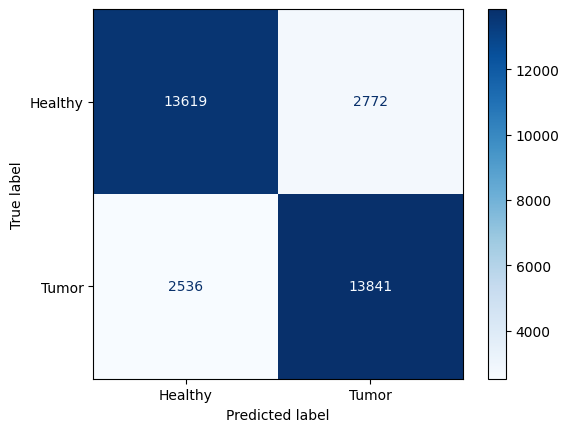

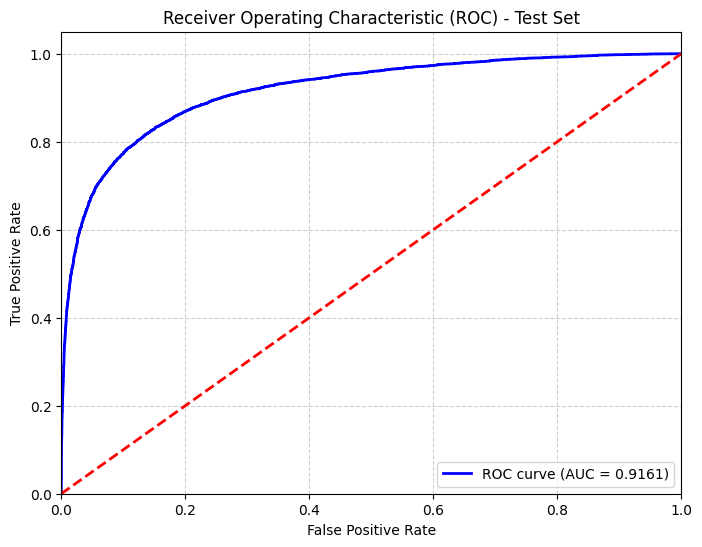

Evaluation complete. Test HDF5 streams closed correctly. Final Test AUC: 0.9161


In [ ]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, applications
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. PREPARAZIONE FILE ---
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)

# --- 2. CARICAMENTO DATI ---
def load_to_ram(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:num_samples].reshape(-1, 1).astype('float32')
    with h5py.File(x_path, 'r') as fx:
        x_all = fx['x'][:num_samples]
    return x_all, y_all

X_train, Y_train = load_to_ram('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
X_val, Y_val = load_to_ram('/content/camelyonpatch_level_2_split_valid_x.h5',
                                    '/content/camelyonpatch_level_2_split_valid_y.h5', 8000)

# --- 3. DATA AUGMENTATION (Adattata per DenseNet) ---
def augment(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 96, 96)
    image = tf.cast(image, tf.float32)
    image = applications.densenet.preprocess_input(image)

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.15)
    #MODIFICATO QUI: aggiunto contrasto
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    return image, label

def process_val(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 96, 96)
    image = tf.cast(image, tf.float32)
    image = applications.densenet.preprocess_input(image)
    return image, label

# Funzione per mappare solo le immagini nel generatore di test dello streaming
def process_test_img(image):
    image = tf.image.resize_with_crop_or_pad(image, 96, 96)
    image = tf.cast(image, tf.float32)
    image = applications.densenet.preprocess_input(image)
    return image

# --- 4. ARCHITETTURA TRANSFER LEARNING ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def build_transfer_model():
    base_model = applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    #MODIFICATO QUI: bloccato i liveeli tranne gli ultimi 30
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    return base_model, model

base_model, model = build_transfer_model()

# --- 5. TRAINING PHASE IN DUE STEP ---
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))\
    .shuffle(10000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))\
    .map(process_val, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# STEP 1: Warm-up
print("\n--- Fase 1: Warm-up ---")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.fit(train_ds, validation_data=val_ds, epochs=3)

# STEP 2: Fine-Tuning (Sblocchiamo tutto)
print("\n--- Fase 2: Fine-Tuning ---")
base_model.trainable = True
class_weights = {0: 1.0, 1: 2.5}
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
              jit_compile=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=class_weights,
                    callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
                               callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=3, verbose=1)])

# PLOT OF FIGURES (Incluso AUC)
plt.figure(figsize=(18,5))

# Loss Curve
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.ylim(0, 1.0); plt.legend()

# Accuracy Curve
plt.subplot(1,3,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.ylim(0, 1.0); plt.legend()

plt.tight_layout()
plt.show()


# --- 6. VALUTAZIONE IN STREAMING (RAM-SAFE) & ROC PLOT ---
print("\n Final evaluation on test set using streaming pipelines...")

# Apriamo i file mantenendoli agganciati al disco per evitare l'overflow della RAM
fx = h5py.File('/content/camelyonpatch_level_2_split_test_x.h5', 'r')
fy = h5py.File('/content/camelyonpatch_level_2_split_test_y.h5', 'r')

X_dataset = fx['x']
Y_test = fy['y'][:].reshape(-1, 1).astype('float32') # Solo i tag binari vengono letti del tutto
num_test_samples = X_dataset.shape[0]

# Generatore per lo streaming sequenziale dei tensori uint8
def test_generator():
    for i in range(num_test_samples):
        yield X_dataset[i]

test_ds = tf.data.Dataset.from_generator(
    test_generator,
    output_signature=tf.TensorSpec(shape=(96, 96, 3), dtype=tf.uint8)
)

# Applichiamo il preprocessing formale di DenseNet e il batching
test_ds = test_ds.map(process_test_img, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Predizione probabilistica distribuita
y_pred_prob = model.predict(test_ds)

# Soglia clinica ottimizzata per lo screening
threshold = 0.35
y_pred = (y_pred_prob > threshold).astype(int)

print(f"\n--- Final report (Threshold: {threshold}) ---")
print(classification_report(Y_test, y_pred, target_names=["Healthy","Tumor"]))

# Matrice di Confusione
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues', values_format='d'); plt.show()

# --- GRAFICO DELLA CURVA ROC E CALCOLO AUC FINALE ---
fpr, tpr, thresholds_roc = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.4f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) - Test Set")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Chiudiamo in sicurezza i flussi di input/output h5
fx.close()
fy.close()
print(f"Evaluation complete. Test HDF5 streams closed correctly. Final Test AUC: {roc_auc:.4f}")